<a href="https://colab.research.google.com/github/SwaRad69/Bangalore-Navigator/blob/main/experiments/raw_vqc_2/raw_vqc_data_structured_cluster_clean_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane matplotlib
!pip install tqdm



In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import os, json

# =========================
# CONFIG
# =========================
DATASET_NAME = "structured_cluster"   # change if needed

# Your dataset is directly in /content
DATA_DIR = "/content"

RESULTS_DIR = f"/content/results/raw_vqc/{DATASET_NAME}"
os.makedirs(RESULTS_DIR, exist_ok=True)

N_QUBITS = 10
DEPTHS = [1,2,3,4,5,6,7,8]
LR = 0.1
EPOCHS = 5
SEED = 42
np.random.seed(SEED)

print("Setup done.")


Setup done.


In [ ]:
# =========================
# LOAD DATA
# =========================
data = np.load(f"{DATA_DIR}/{DATASET_NAME}.npz")

X = data["X"]
y = data["y"]

print("Data shape:", X.shape)
print("Labels shape:", y.shape)
print("First sample:", X[0])


Data shape: (500, 10)
Labels shape: (500,)
First sample: [1.40539821 2.46039237 2.18798135 2.12125851 2.37914209 1.64819022
 2.41357535 0.84029066 1.53726214 1.18542527]


In [ ]:
# =========================
# DEVICE
# =========================
dev = qml.device("default.qubit", wires=N_QUBITS)

# =========================
# CIRCUIT
# =========================
def encode(x):
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)

def layer(w):
    for i in range(N_QUBITS):
        qml.RY(w[i], wires=i)
    for i in range(N_QUBITS-1):
        qml.CNOT(wires=[i, i+1])

@qml.qnode(dev, interface="autograd")
def circuit(x, weights):
    encode(x)
    for w in weights:
        layer(w)
    return qml.expval(qml.PauliZ(0))

print("Circuit ready.")


Circuit ready.


In [ ]:
# =========================
# DEVICE
# =========================
dev = qml.device("default.qubit", wires=N_QUBITS)

# =========================
# CIRCUIT
# =========================
def encode(x):
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)

def layer(w):
    for i in range(N_QUBITS):
        qml.RY(w[i], wires=i)
    for i in range(N_QUBITS-1):
        qml.CNOT(wires=[i, i+1])

@qml.qnode(dev, interface="autograd")
def circuit(x, weights):
    encode(x)
    for w in weights:
        layer(w)
    return qml.expval(qml.PauliZ(0))

print("Circuit ready.")


Circuit ready.


In [ ]:
# =========================
# LOSS
# =========================
def loss(weights, x, label):
    pred = circuit(x, weights)
    return (pred - (2*label - 1))**2   # map label 0/1 -> -1/+1

# =========================
# GRAD VARIANCE
# =========================
def grad_variance(weights, x, label):
    grad_fn = qml.grad(loss)
    g = grad_fn(weights, x, label)
    flat = np.concatenate([gi.flatten() for gi in g])
    return np.var(flat)

print("Loss + gradient ready.")


Loss + gradient ready.


In [ ]:
from tqdm.notebook import tqdm
from pennylane import numpy as np


SEEDS = [11, 22, 33]   # 3 runs
all_runs = []

for seed in SEEDS:
    print(f"\n===== Running seed {seed} =====")
    np.random.seed(seed)

    depth_vs_var = {}

    for depth in tqdm(DEPTHS, desc=f"Depth sweep (seed {seed})"):

        weights = np.random.normal(0, 0.1, size=(depth, N_QUBITS))
        weights = np.array(weights, requires_grad=True)

        opt = qml.GradientDescentOptimizer(LR)

        grad_vars = []

        for epoch in range(EPOCHS):
            for xi, yi in zip(X, y):
                weights = opt.step(lambda w: loss(w, xi, yi), weights)

            gv = grad_variance(weights, X[0], y[0])
            grad_vars.append(gv)

        depth_vs_var[depth] = float(np.mean(grad_vars))

    all_runs.append(depth_vs_var)

print("\nAll seeds finished.")



===== Running seed 11 =====


Depth sweep (seed 11):   0%|          | 0/8 [00:00<?, ?it/s]


===== Running seed 22 =====


Depth sweep (seed 22):   0%|          | 0/8 [00:00<?, ?it/s]


===== Running seed 33 =====


Depth sweep (seed 33):   0%|          | 0/8 [00:00<?, ?it/s]


All seeds finished.


In [ ]:
# =========================
# Convert all keys safely to int
# =========================

clean_runs = []

for run in all_runs:
    clean_dict = {}
    for k, v in run.items():
        # convert ANY key type → int
        k_clean = int(np.array(k).item())
        v_clean = float(np.array(v).item())
        clean_dict[k_clean] = v_clean
    clean_runs.append(clean_dict)

# =========================
# Get sorted depth list
# =========================
depths = sorted(clean_runs[0].keys())

# =========================
# Build value matrix safely
# =========================
vals = []

for run in clean_runs:
    row = []
    for d in depths:
        row.append(run[d])
    vals.append(row)

vals = np.array(vals, dtype=float)

mean_curve = vals.mean(axis=0)
std_curve  = vals.std(axis=0)

print("Depths:", depths)
print("Mean gradient variance:", mean_curve)


Depths: [1, 2, 3, 4, 5, 6, 7, 8]
Mean gradient variance: [1.30614585e-06 4.15763763e-07 1.59927801e-08 9.38958608e-08
 1.77258218e-07 7.23068224e-07 8.32135219e-07 1.66572160e-07]


In [ ]:
import json, os

RESULTS_DIR = f"/content/results/raw_vqc/{DATASET_NAME}"
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(f"{RESULTS_DIR}/results.json", "w") as f:
    json.dump(depth_vs_var, f, indent=4)

print("Results saved to:", RESULTS_DIR)


Results saved to: /content/results/raw_vqc/structured_cluster


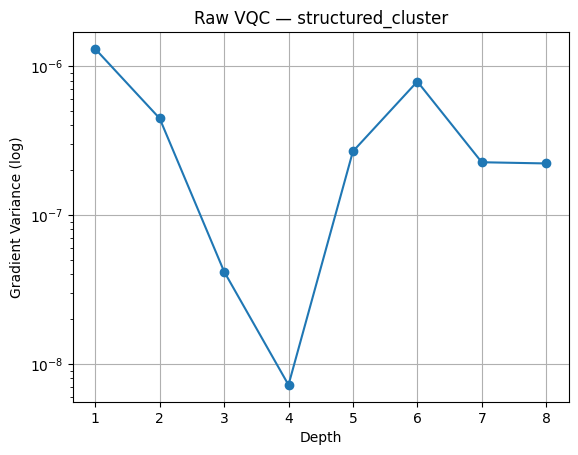

Plot saved.


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(list(depth_vs_var.keys()), list(depth_vs_var.values()), marker='o')
plt.yscale("log")
plt.xlabel("Depth")
plt.ylabel("Gradient Variance (log)")
plt.title(f"Raw VQC — {DATASET_NAME}")
plt.grid(True)

plt.savefig(f"{RESULTS_DIR}/plot.png", dpi=300)
plt.show()

print("Plot saved.")


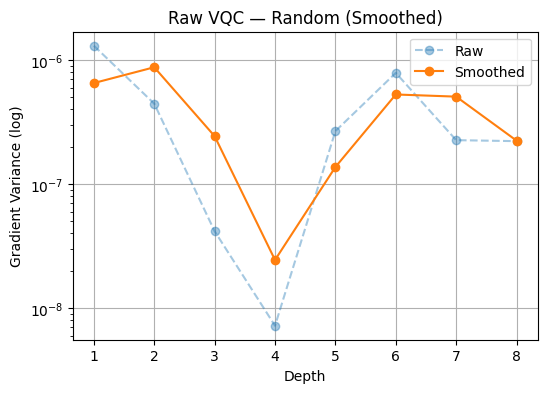

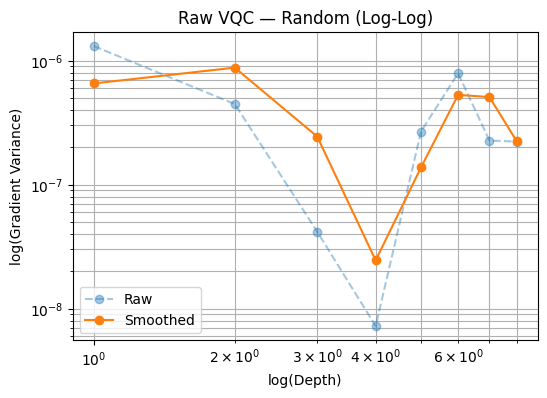

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert dict → arrays
depths = np.array(list(depth_vs_var.keys()), dtype=float)
vars_  = np.array(list(depth_vs_var.values()), dtype=float)

# =========================
# Moving average smoothing
# =========================
window = 2   # small smoothing (don't over-smooth)

def moving_average(x, w):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="same")

vars_smooth = moving_average(vars_, window)

# =========================
# Plot 1 — Normal log plot (smoothed)
# =========================
plt.figure(figsize=(6,4))
plt.plot(depths, vars_, 'o--', alpha=0.4, label="Raw")
plt.plot(depths, vars_smooth, 'o-', label="Smoothed")
plt.yscale("log")
plt.xlabel("Depth")
plt.ylabel("Gradient Variance (log)")
plt.title("Raw VQC — Random (Smoothed)")
plt.grid(True)
plt.legend()
plt.show()

# =========================
# Plot 2 — Log-Log plot
# =========================
plt.figure(figsize=(6,4))
plt.plot(depths, vars_, 'o--', alpha=0.4, label="Raw")
plt.plot(depths, vars_smooth, 'o-', label="Smoothed")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("log(Depth)")
plt.ylabel("log(Gradient Variance)")
plt.title("Raw VQC — Random (Log-Log)")
plt.grid(True, which="both")
plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/results/raw_vqc/random_plateau/errorbar_plot.png'

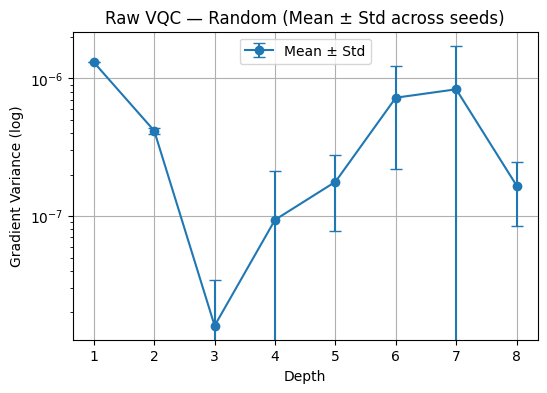

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

depths = np.array(depths, dtype=float)

# =========================
# Plot — Mean with error bars
# =========================
plt.figure(figsize=(6,4))

plt.errorbar(
    depths,
    mean_curve,
    yerr=std_curve,
    fmt='o-',
    capsize=4,
    label="Mean ± Std"
)

plt.yscale("log")
plt.xlabel("Depth")
plt.ylabel("Gradient Variance (log)")
plt.title("Raw VQC — Random (Mean ± Std across seeds)")
plt.grid(True)
plt.legend()


plt.show()
